In [1]:
import numpy as np
import sympy as sp
from matplotlib import pyplot as plt

EJERCICIO 1


item a


In [2]:
def f(x):
  res = np.exp(np.sin(x))
  return res
X = sp.symbols("x")
f_sym = sp.exp(sp.sin(X))
df_exacta = sp.diff(f_sym, X)

In [3]:
def df_exacta_func(x):
  res = np.exp(np.sin(x))*np.cos(x)
  return res

In [4]:
a = 0
b = 2*np.pi
n = [4,6,8,10]

In [5]:
def trapecios_compuesta(f,a,b,n):
  h = (b-a)/n
  x = np.linspace(a,b,n+1)
  y = f(x)
  suma_intermedios = np.sum(y[1:-1])
  I_aprox = (h / 2) * (y[0] + 2 * suma_intermedios + y[-1])
  return I_aprox

In [6]:
n_ref = 2**14
I_ref = trapecios_compuesta(f, a, b, n_ref)

print(f"ITEM (A) - PUNTO 2: Solución de Referencia")
print(f"I_ref (n={n_ref}) = {I_ref:.16f}")

ITEM (A) - PUNTO 2: Solución de Referencia
I_ref (n=16384) = 7.9549265210128457


In [7]:
print("ITEM (A) - PUNTO 3: Cálculo de Errores Globales")
errores = []
for i in n:
    Q_i = trapecios_compuesta(f, a, b, i)
    E_i = np.abs(I_ref - Q_i)
    errores.append(E_i)

ITEM (A) - PUNTO 3: Cálculo de Errores Globales


In [8]:
print(errores)


[np.float64(0.03439691880919149), np.float64(0.0002826008482141873), np.float64(1.2516889320579594e-06), np.float64(3.4594558329104075e-09)]


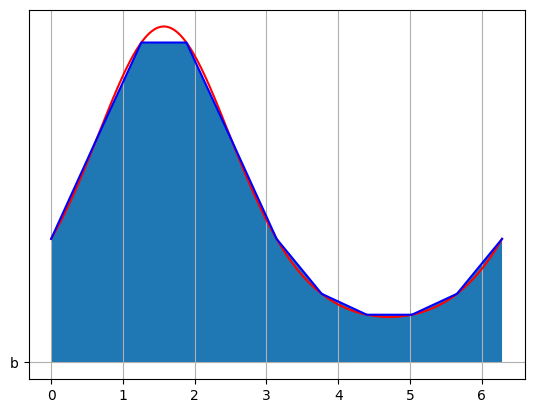

In [9]:
vals_x = np.linspace(a,b,1000)
vals_y = f(vals_x)
for i in n:
  x_1 = np.linspace(a,b,i+1)
  x_2 = f(x_1)
plt.fill_between(x_1,x_2,"b")
plt.plot(vals_x,vals_y,"r-")
plt.plot(x_1,x_2,"b-")
plt.grid()
plt.show()

item b

1

In [10]:
for i in n:
  j = np.arange(2*i+1)
  x_j = (2*(np.pi)*j)/(2*i+1)
  y_j = f(x_j)

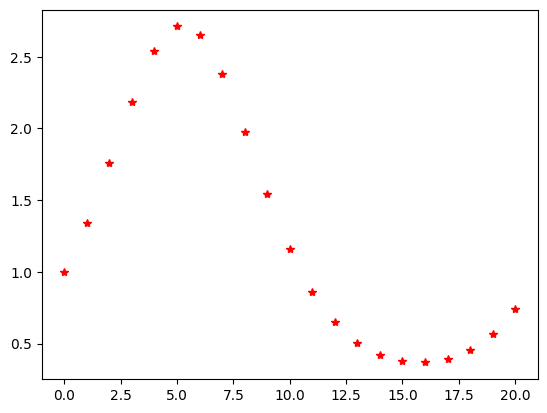

In [11]:
plt.plot(y_j,"r*")
plt.show()

In [24]:
vals_x =  np.linspace(delta,2*np.pi-delta,1000)

tabla_resultados = []
for i in n:
  j = np.arange(2*i+1)
  x_j = (2*(np.pi)*j)/(2*i+1)
  y_j = f(x_j)
  #calculo coef fourier discretos
  y_fft = np.fft.fft(y_j)
  coeficientes_complejos = y_fft / (2*i+1)
  c_ordenados = np.fft.fftshift(coeficientes_complejos)
  #interp trigonometrico
  v = np.arange(-i, i+1)
  y_interpol = np.zeros_like(vals_x, dtype=complex)
  df_interp =np.zeros_like(vals_x,dtype=complex)
  for k,c in zip(v, c_ordenados):
    termino = c*(np.exp(1j*k*(vals_x)))
    y_interpol += termino
    termino_derivado = c * (1j*k)*np.exp(1j*k*(vals_x))
    df_interp += termino_derivado

  y_interpol = np.real(y_interpol)
  df_interp = np.real(df_interp)
  delta = 0.1
  valores_1 = np.linspace(delta,2*np.pi-delta,1000)
  valores_2 = f(valores_1)
  error_f = np.max(np.abs(valores_2 - y_interpol))
  df_valores_2 = df_exacta_func(valores_1)
  error_df = np.max(np.abs(df_valores_2 - df_interp))
  tabla_resultados.append((i,error_f,error_df))
  print("tabla de errores norma infinito")
  for n_val,error_f,error_df in tabla_resultados:
    print(f"{n_val} | {error_f}|{error_df}")

tabla de errores norma infinito
4 | 0.0011098645713174538|0.004949820402279759
tabla de errores norma infinito
4 | 0.0011098645713174538|0.004949820402279759
6 | 6.4718705643507235e-06|4.202948366072157e-05
tabla de errores norma infinito
4 | 0.0011098645713174538|0.004949820402279759
6 | 6.4718705643507235e-06|4.202948366072157e-05
8 | 2.2234931007503178e-08|1.890805638726789e-07
tabla de errores norma infinito
4 | 0.0011098645713174538|0.004949820402279759
6 | 6.4718705643507235e-06|4.202948366072157e-05
8 | 2.2234931007503178e-08|1.890805638726789e-07
10 | 5.020295290592003e-11|5.274209957661924e-10


tabla de errores norma infinito
10 | 0.12112211404630102|0.1445294171551323


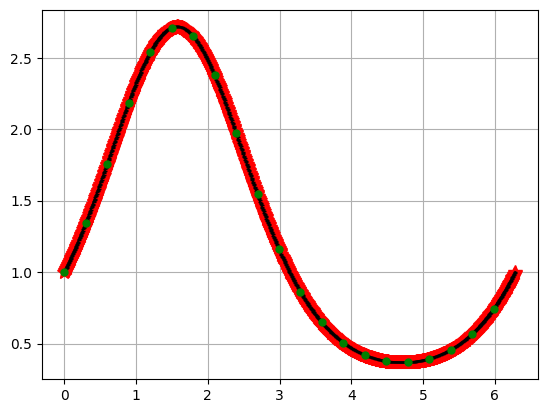

In [14]:
# GRAFICO
plt.plot(vals_x,vals_y,marker = "*", markersize = 10,color = "red")
plt.plot(vals_x,y_interpol,marker="_",markersize = 3,color="black")
plt.plot(x_j,y_j,"go",markersize=5)
plt.grid()
plt.show()

EJERCICIO 2

aproximacion de truncamiento duro



In [15]:
def integrando_original(t,omega):
  return np.sin(omega*t**2)

In [16]:
def ventana_dura(t,T):
  return np.where(np.abs(t) <= T, 1.0, 0.0)
def ventana_suave(t,alpha):
  return np.exp(-alpha*t**2)

In [17]:
def integrando_ventana_dura(t,omega,T):
  return integrando_original(t,omega)*ventana_dura(t,T)


aproximacion de truncamiento por ventana suave

In [18]:
def integrando_ventana_suave(t,omega,alpha):
  return integrando_original(t,omega)*ventana_suave(t,alpha)

In [19]:
# PARAMETROS PARA COMPARAR

In [20]:
omega = 1.0
T_corte = 6.0
alpha_suave = 0.03

In [21]:
I_dura = integrando_ventana_dura(-T_corte,omega,T_corte)
I_suave = integrando_ventana_suave(-T_corte,omega,alpha_suave)

resultado ventana dura (Integral): 1.2768815082246683
resultado ventana suave (Integral): 1.2437736212456136


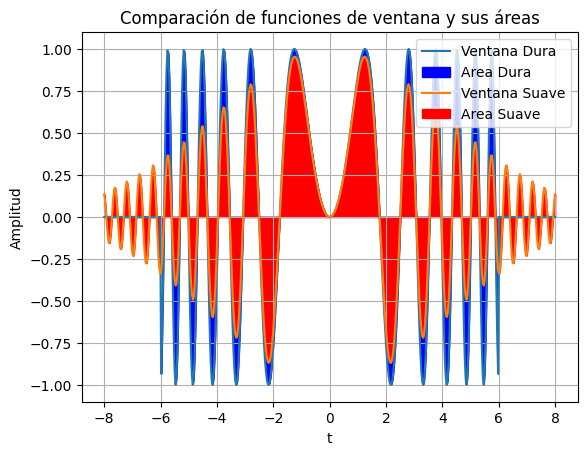

In [22]:
t = np.linspace(-8, 8, 500)
I_dura_valores = integrando_ventana_dura(t,omega,T_corte)
I_suave_valores = integrando_ventana_suave(t, omega, alpha_suave)

n_pasos = 1000

area_dura = trapecios_compuesta(lambda x: integrando_ventana_dura(x, omega, T_corte), -T_corte, T_corte, n_pasos)
area_suave = trapecios_compuesta(lambda x: integrando_ventana_suave(x, omega, alpha_suave), -T_corte, T_corte, n_pasos)

print(f"resultado ventana dura (Integral): {area_dura}")
print(f"resultado ventana suave (Integral): {area_suave}")

plt.plot(t, I_dura_valores, label='Ventana Dura')
plt.fill_between(t, I_dura_valores, color='blue', label='Area Dura')
plt.plot(t, I_suave_valores, label='Ventana Suave')
plt.fill_between(t, I_suave_valores, color='red', label='Area Suave')
plt.grid()
plt.legend()
plt.xlabel('t')
plt.ylabel('Amplitud')
plt.title('Comparación de funciones de ventana y sus áreas')
plt.show()